# Chapter 2: Complex Vector Spaces

Quantum theory is written in the language of complex vector spaces. In Chapter 1 we learned to work with individual complex numbers. Now we assemble them into vectors and matrices, the structures that describe quantum states and the operations that change them.

This chapter covers the core linear algebra needed for quantum computing: vector addition and scalar multiplication, matrices, inner products, eigenvalues, Hermitian and unitary matrices, and tensor products. Each section builds on the last, and by the end you will have every tool required to read a quantum circuit diagram and know exactly what it computes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, eig, inv

np.set_printoptions(precision=4, suppress=True)
# Helper: shorthand for column vectors
def cvec(*entries):
    """Return a complex column vector from the given entries."""
    return np.array(entries, dtype=complex).reshape(-1, 1)

def ket_str(v):
    """Pretty-print a column vector."""
    return str(v.flatten())

## 2.1 $\mathbb{C}^n$ as the Primary Example

Think of a shopping list. Each line holds one item (a number), and the order of the lines matters: eggs on line 1 is different from eggs on line 3. A vector in $\mathbb{C}^n$ is the same idea, except each entry is a complex number and there are exactly $n$ of them.

A typical element of $\mathbb{C}^4$:

In [2]:
V = cvec(6-4j, 7+3j, 4.2-8.1j, -3j)
print('V =')
print(V)

V =
[[ 6. -4.j ]
 [ 7. +3.j ]
 [ 4.2-8.1j]
 [-0. -3.j ]]


### Vector Addition

Adding two vectors means adding their corresponding entries, just as you would combine two shopping lists line by line.

In [3]:
V = cvec(6-4j, 7+3j, 4.2-8.1j, -3j)
W = cvec(16+2.3j, -7j, 6, -4j)

print('V + W =')
print(V + W)

# Commutativity: V + W == W + V
print('\nW + V =')
print(W + V)
assert np.allclose(V + W, W + V), 'Addition should be commutative'

V + W =
[[22. -1.7j]
 [ 7. -4.j ]
 [10.2-8.1j]
 [-0. -7.j ]]

W + V =
[[22. -1.7j]
 [ 7. -4.j ]
 [10.2-8.1j]
 [-0. -7.j ]]


### The Zero Vector and Additive Inverse

Every vector space has a zero vector (all entries 0) that acts as the identity for addition, and every vector $V$ has an inverse $-V$ such that $V + (-V) = \mathbf{0}$.

In [4]:
zero = cvec(0, 0, 0, 0)
print('V + 0 =', (V + zero).flatten())
print('V + (-V) =', (V + (-V)).flatten())

V + 0 = [6. -4.j  7. +3.j  4.2-8.1j 0. -3.j ]
V + (-V) = [0.+0.j 0.+0.j 0.+0.j 0.+0.j]


### Scalar Multiplication

Multiplying a vector by a complex scalar $c$ scales every entry by $c$. If the scalar is real, this stretches or shrinks the vector. If it has an imaginary part, the entries rotate in the complex plane as well.

In [5]:
c = 3 + 2j
V2 = cvec(6+3j, 0, 5+1j, 4)
print('c * V =')
print(c * V2)

c * V =
[[12.+21.j]
 [ 0. +0.j]
 [13.+13.j]
 [12. +8.j]]


### Exercise 2.1.1

Add the following two vectors:

$$\begin{bmatrix} 5+13i \\ 6+2i \\ 0.53-6i \\ 12 \end{bmatrix} + \begin{bmatrix} 7-8i \\ 4i \\ 2 \\ 9.4+3i \end{bmatrix}$$

In [6]:
a = cvec(5+13j, 6+2j, 0.53-6j, 12)
b = cvec(7-8j, 4j, 2, 9.4+3j)
print('Sum =')
print(a + b)

Sum =
[[12.  +5.j]
 [ 6.  +6.j]
 [ 2.53-6.j]
 [21.4 +3.j]]


### Exercise 2.1.2

Prove the associativity property: $(V + W) + X = V + (W + X)$.

**Proof.** For each index $j$:

$$((V+W)+X)[j] = (V[j]+W[j])+X[j] = V[j]+(W[j]+X[j]) = (V+(W+X))[j]$$

The middle step uses associativity of complex addition. $\square$

In [7]:
# Numerical check
X = cvec(1+1j, 2-1j, 3, 4+2j)
assert np.allclose((V + W) + X, V + (W + X))
print('Associativity verified.')

Associativity verified.


### Exercise 2.1.3

Scalar multiply $8 - 2i$ with $\begin{bmatrix} 16+2.3i \\ -7i \\ 6 \\ 5-4i \end{bmatrix}$.

In [8]:
s = 8 - 2j
v = cvec(16+2.3j, -7j, 6, 5-4j)
print('(8-2i) * v =')
print(s * v)

(8-2i) * v =
[[132.6-13.6j]
 [-14. -56.j ]
 [ 48. -12.j ]
 [ 32. -42.j ]]


### Exercise 2.1.4

Prove that $(c_1 + c_2) \cdot V = c_1 \cdot V + c_2 \cdot V$.

**Proof.** For each index $j$:

$$((c_1+c_2)\cdot V)[j] = (c_1+c_2) \times V[j] = c_1 \times V[j] + c_2 \times V[j]$$

by distributivity of complex multiplication over addition. $\square$

In [9]:
c1, c2 = 3+1j, 2-2j
v = cvec(1+1j, 2, 3-1j)
assert np.allclose((c1+c2)*v, c1*v + c2*v)
print('Distributivity verified.')

Distributivity verified.


### Programming Drill 2.1.1

Write three functions that perform addition, inverse, and scalar multiplication for $\mathbb{C}^n$.

In [10]:
def vec_add(v, w):
    """Add two complex vectors."""
    return v + w

def vec_inv(v):
    """Additive inverse of a complex vector."""
    return -v

def vec_scalar(c, v):
    """Scalar multiply c * v."""
    return c * v

# Test
a = cvec(1+2j, 3-1j)
b = cvec(4, 2+5j)
print('add:', vec_add(a, b).flatten())
print('inv:', vec_inv(a).flatten())
print('scalar:', vec_scalar(2+1j, a).flatten())

add: [5.+2.j 5.+4.j]
inv: [-1.-2.j -3.+1.j]
scalar: [0.+5.j 7.+1.j]


## 2.2 Definitions, Properties, and Examples

The patterns we just saw in $\mathbb{C}^n$ (addition, inverse, scalar multiplication, and the eight properties they satisfy) define the abstract notion of a **complex vector space**. Any set $\mathbb{V}$ with these three operations and a zero element, satisfying the eight axioms (commutativity, associativity, identity, inverse, unit scalar, and three distributive laws), is a complex vector space.

A **real vector space** replaces complex scalars with real ones. Every complex vector space is automatically a real vector space too, since $\mathbb{R} \subset \mathbb{C}$.

### Matrices as Vectors

The set $\mathbb{C}^{m \times n}$ of all $m$-by-$n$ complex matrices is itself a complex vector space. Addition, inverse, and scalar multiplication all work entry by entry, exactly as they do for column vectors.

In [11]:
A = np.array([[1+2j, 3], [4, 5-1j]])
B = np.array([[2-1j, 0], [1+1j, 3+2j]])
print('A + B =')
print(A + B)
print('\n3 * A =')
print(3 * A)

A + B =
[[3.+1.j 3.+0.j]
 [5.+1.j 8.+1.j]]

3 * A =
[[ 3.+6.j  9.+0.j]
 [12.+0.j 15.-3.j]]


### Transpose, Conjugate, and Adjoint

Three operations on square matrices appear constantly in quantum computing:

- The **transpose** $A^T$ flips rows and columns: $A^T[j,k] = A[k,j]$.
- The **conjugate** $\bar{A}$ conjugates every entry.
- The **adjoint** (or **dagger**) $A^\dagger = (\bar{A})^T$ does both at once.

The adjoint is the single most important matrix operation in quantum mechanics.

In [12]:
A = np.array([[6-3j, 2+12j, -19j],
              [0, 5+2.1j, 17],
              [1, 2+5j, 3-4.5j]])

print('A =')
print(A)
print('\nTranspose A^T =')
print(A.T)
print('\nConjugate conj(A) =')
print(A.conj())
print('\nAdjoint A^dagger =')
print(A.conj().T)

A =
[[ 6. -3.j   2.+12.j  -0.-19.j ]
 [ 0. +0.j   5. +2.1j 17. +0.j ]
 [ 1. +0.j   2. +5.j   3. -4.5j]]

Transpose A^T =
[[ 6. -3.j   0. +0.j   1. +0.j ]
 [ 2.+12.j   5. +2.1j  2. +5.j ]
 [-0.-19.j  17. +0.j   3. -4.5j]]

Conjugate conj(A) =
[[ 6. +3.j   2.-12.j  -0.+19.j ]
 [ 0. -0.j   5. -2.1j 17. -0.j ]
 [ 1. -0.j   2. -5.j   3. +4.5j]]

Adjoint A^dagger =
[[ 6. +3.j   0. -0.j   1. -0.j ]
 [ 2.-12.j   5. -2.1j  2. -5.j ]
 [-0.+19.j  17. -0.j   3. +4.5j]]


### Exercise 2.2.1

Let $r_1 = 2$, $r_2 = 3$, and $V = \begin{bmatrix} 2 \\ -4 \\ 1 \end{bmatrix}$. Verify Property (vi): $r_1 \cdot (r_2 \cdot V) = (r_1 \times r_2) \cdot V$.

In [13]:
r1, r2 = 2, 3
V = cvec(2, -4, 1)
lhs = r1 * (r2 * V)
rhs = (r1 * r2) * V
print('r1*(r2*V) =', lhs.flatten())
print('(r1*r2)*V =', rhs.flatten())
assert np.allclose(lhs, rhs)
print('Property (vi) verified.')

r1*(r2*V) = [ 12.+0.j -24.+0.j   6.+0.j]
(r1*r2)*V = [ 12.+0.j -24.+0.j   6.+0.j]
Property (vi) verified.


### Exercise 2.2.3

Let $c_1 = 2i$, $c_2 = 1+2i$, and $A = \begin{bmatrix} 1-i & 3 \\ 2+2i & 4+i \end{bmatrix}$. Verify Properties (vi) and (viii) for $\mathbb{C}^{2 \times 2}$.

In [14]:
c1, c2 = 2j, 1+2j
A = np.array([[1-1j, 3], [2+2j, 4+1j]])

# Property (vi): c1*(c2*A) = (c1*c2)*A
assert np.allclose(c1*(c2*A), (c1*c2)*A)
print('Property (vi) verified.')

# Property (viii): (c1+c2)*A = c1*A + c2*A
assert np.allclose((c1+c2)*A, c1*A + c2*A)
print('Property (viii) verified.')

Property (vi) verified.
Property (viii) verified.


### Exercise 2.2.4

Show that the operations on $\mathbb{C}^{m \times n}$ satisfy Properties (v), (vi), and (viii).

**Proof sketch.** Each property reduces to the corresponding property of complex number arithmetic applied entry by entry. For example, Property (v): $(1 \cdot A)[j,k] = 1 \times A[j,k] = A[j,k]$. Properties (vi) and (viii) follow from associativity and distributivity of complex multiplication. $\square$

### Exercise 2.2.5

Find the transpose, conjugate, and adjoint of the matrix
$$\begin{bmatrix} 6-3i & 2+12i & -19i \\ 0 & 5+2.1i & 17 \\ 1 & 2+5i & 3-4.5i \end{bmatrix}$$

In [15]:
A = np.array([[6-3j, 2+12j, -19j],
              [0, 5+2.1j, 17],
              [1, 2+5j, 3-4.5j]])

print('Transpose:')
print(A.T)
print('\nConjugate:')
print(A.conj())
print('\nAdjoint (dagger):')
print(A.conj().T)

Transpose:
[[ 6. -3.j   0. +0.j   1. +0.j ]
 [ 2.+12.j   5. +2.1j  2. +5.j ]
 [-0.-19.j  17. +0.j   3. -4.5j]]

Conjugate:
[[ 6. +3.j   2.-12.j  -0.+19.j ]
 [ 0. -0.j   5. -2.1j 17. -0.j ]
 [ 1. -0.j   2. -5.j   3. +4.5j]]

Adjoint (dagger):
[[ 6. +3.j   0. -0.j   1. -0.j ]
 [ 2.-12.j   5. -2.1j  2. -5.j ]
 [-0.+19.j  17. -0.j   3. +4.5j]]


### Exercise 2.2.6

Prove that conjugation respects scalar multiplication: $\overline{c \cdot A} = \bar{c} \cdot \bar{A}$.

**Proof.** For each entry: $\overline{(c \cdot A)[j,k]} = \overline{c \times A[j,k]} = \bar{c} \times \overline{A[j,k]} = (\bar{c} \cdot \bar{A})[j,k]$. $\square$

### Exercise 2.2.7

Prove Properties (vii), (viii), and (ix) using Properties (i) through (vi).

**Property (vii):** $(A^\dagger)^\dagger = A$. Taking the adjoint means conjugate then transpose. Doing it twice: $(\overline{\overline{A}^T})^T$. Conjugate is idempotent ($\overline{\overline{z}} = z$) and transpose is idempotent ($(A^T)^T = A$), so this returns $A$.

**Property (viii):** $(A+B)^\dagger = A^\dagger + B^\dagger$. Transpose and conjugate each respect addition (properties ii and v), so their composition does too.

**Property (ix):** $(c \cdot A)^\dagger = \bar{c} \cdot A^\dagger$. $(c \cdot A)^\dagger = (\overline{c \cdot A})^T = (\bar{c} \cdot \bar{A})^T = \bar{c} \cdot \bar{A}^T = \bar{c} \cdot A^\dagger$. $\square$

### Matrix Multiplication

To multiply two matrices $A$ and $B$, each entry of the product is a dot product: row $j$ of $A$ dotted with column $k$ of $B$. The number of columns of $A$ must equal the number of rows of $B$.

Matrix multiplication is associative and distributes over addition, but it is *not* commutative. This non-commutativity turns out to be deeply important in quantum mechanics.

In [16]:
A = np.array([[3+2j, 0, 5-6j],
              [1, 4+2j, 1j],
              [4-1j, 0, 4]])

B = np.array([[5, 2-1j, 6-4j],
              [0, 4+5j, 2],
              [7-4j, 2+7j, 0]])

print('A @ B =')
print(A @ B)

print('\nB @ A =')
print(B @ A)

print('\nA @ B == B @ A?', np.allclose(A @ B, B @ A))

A @ B =
[[26.-52.j 60.+24.j 26. +0.j]
 [ 9. +7.j  1.+29.j 14. +0.j]
 [48.-21.j 15.+22.j 20.-22.j]]

B @ A =
[[37.-13.j 10. +0.j 50.-44.j]
 [12. +3.j  6.+28.j  3. +4.j]
 [31. +9.j -6.+32.j  4.-60.j]]

A @ B == B @ A? False


### Exercise 2.2.8

Compute $B \star A$ using $A$ and $B$ above. Does it equal $A \star B$?

In [17]:
print('B @ A =')
print(B @ A)
print('\nEqual to A @ B?', np.allclose(A @ B, B @ A))

B @ A =
[[37.-13.j 10. +0.j 50.-44.j]
 [12. +3.j  6.+28.j  3. +4.j]
 [31. +9.j -6.+32.j  4.-60.j]]

Equal to A @ B? False


### Exercise 2.2.9

Prove Property (v): $(A \star B)^T = B^T \star A^T$.

**Proof.** $(A \star B)^T[j,k] = (A \star B)[k,j] = \sum_h A[k,h] \cdot B[h,j]$. Meanwhile, $(B^T \star A^T)[j,k] = \sum_h B^T[j,h] \cdot A^T[h,k] = \sum_h B[h,j] \cdot A[k,h]$, which equals the above since multiplication of complex numbers is commutative. $\square$

In [18]:
assert np.allclose((A @ B).T, B.T @ A.T)
print('(A*B)^T = B^T * A^T verified.')

(A*B)^T = B^T * A^T verified.


### Exercise 2.2.10

Show that $(A \star B)^\dagger = B^\dagger \star A^\dagger$.

In [19]:
Ad = lambda M: M.conj().T
assert np.allclose(Ad(A @ B), Ad(B) @ Ad(A))
print('(A*B)^dagger = B^dagger * A^dagger verified.')

(A*B)^dagger = B^dagger * A^dagger verified.


### Exercise 2.2.11

Prove Property (vii) from Properties (v) and (vi).

**Proof.** $(A \star B)^\dagger = \overline{(A \star B)}^T = \overline{(A \star B)^T} $ (conjugate and transpose commute). By Property (v): $= \overline{B^T \star A^T}$. By Property (vi): $= \bar{B}^T \star \bar{A}^T = B^\dagger \star A^\dagger$. $\square$

### The Identity Matrix and Matrix Action

The $n \times n$ identity matrix $I_n$ has 1s on the diagonal and 0s elsewhere. It acts as a multiplicative identity: $I_n \star A = A = A \star I_n$.

When a square matrix $A$ multiplies a column vector $V$, we get a new vector. Matrices *act* on vectors, transforming one quantum state into another. This is the bridge between abstract linear algebra and physical reality: the state of a quantum system is a vector, and the things that happen to it are matrices.

In [20]:
I3 = np.eye(3, dtype=complex)
v = cvec(1+1j, 2, 3-1j)
print('I @ v =', (I3 @ v).flatten())
print('Same as v?', np.allclose(I3 @ v, v))

I @ v = [1.+1.j 2.+0.j 3.-1.j]
Same as v? True


### Exercise 2.2.12

Show that $Poly_n$ with the standard operations is a complex vector space.

**Proof sketch.** A polynomial $P(x) = c_0 + c_1 x + \cdots + c_n x^n$ is determined by its coefficient vector $(c_0, \ldots, c_n) \in \mathbb{C}^{n+1}$. Addition and scalar multiplication act component-wise on coefficients, inheriting all eight axioms from $\mathbb{C}^{n+1}$. $\square$

### Exercise 2.2.13

Show that $Poly_5$ is a complex subspace of $Poly_7$.

**Proof.** Every polynomial of degree $\leq 5$ is also a polynomial of degree $\leq 7$ (pad with zero coefficients for $x^6$ and $x^7$). The set of such polynomials is closed under addition and scalar multiplication (adding two degree-$\leq 5$ polynomials gives degree $\leq 5$; scaling one does too). So $Poly_5 \subseteq Poly_7$ is a subspace. $\square$

### Exercise 2.2.14

Show that all real matrices of the form $\begin{bmatrix} x & y \\ -y & x \end{bmatrix}$ form a subspace of $\mathbb{R}^{2 \times 2}$ isomorphic to $\mathbb{C}$.

In [21]:
# The map f(x + iy) = [[x, y], [-y, x]] is a linear isomorphism.
def f(z):
    x, y = z.real, z.imag
    return np.array([[x, y], [-y, x]])

z1, z2 = 3+4j, 1-2j
# f respects addition
assert np.allclose(f(z1 + z2), f(z1) + f(z2))
# f respects multiplication (matrix product encodes complex product)
assert np.allclose(f(z1 * z2), f(z1) @ f(z2))
print('Isomorphism verified: f(z1*z2) = f(z1) @ f(z2)')

Isomorphism verified: f(z1*z2) = f(z1) @ f(z2)


### Exercise 2.2.15

Show that $Func(\mathbb{N}, \mathbb{C})$ forms a complex vector space.

**Proof.** Functions $f: \mathbb{N} \to \mathbb{C}$ inherit all vector space axioms from pointwise operations: $(f+g)(n) = f(n)+g(n)$, $(cf)(n) = c \cdot f(n)$. The zero function maps every $n$ to 0. Commutativity, associativity, and distributivity all follow from the same properties of $\mathbb{C}$. $\square$

### Exercise 2.2.16

Show that $Func(\mathbb{N}, \mathbb{R})$ and $Func([a,b], \mathbb{R})$ are real vector spaces.

**Proof.** The same pointwise argument applies with $\mathbb{R}$ in place of $\mathbb{C}$. Since all scalars and function values are real, the closure axioms hold within $\mathbb{R}$. $\square$

### Exercise 2.2.17

Show that $\mathbb{C}^m \times \mathbb{C}^n$ is isomorphic to $\mathbb{C}^{m+n}$.

**Proof.** Map $(V, W) \mapsto [V; W]$ (concatenation). This is a bijection that respects addition and scalar multiplication component-wise. $\square$

In [22]:
# Demonstration: C^2 x C^3 -> C^5
v = cvec(1+1j, 2)
w = cvec(3, 4-1j, 5j)
concatenated = np.vstack([v, w])
print('(V, W) concatenated to C^5:')
print(concatenated.flatten())

(V, W) concatenated to C^5:
[1.+1.j 2.+0.j 3.+0.j 4.-1.j 0.+5.j]


### Exercise 2.2.18

Show that $\mathbb{C}^m$ and $\mathbb{C}^n$ are each a complex subspace of $\mathbb{C}^m \times \mathbb{C}^n$.

**Proof.** Embed $\mathbb{C}^m$ as $\{(V, \mathbf{0}) : V \in \mathbb{C}^m\}$. This subset is closed under addition and scalar multiplication, so it is a subspace. Similarly for $\mathbb{C}^n$ via $(\mathbf{0}, W)$. $\square$

### Programming Drill 2.2.1

Convert the vector functions from Drill 2.1.1 to work with matrices ($\mathbb{C}^{m \times n}$).

In [23]:
def mat_add(A, B):
    return A + B

def mat_inv(A):
    return -A

def mat_scalar(c, A):
    return c * A

A = np.array([[1+1j, 2], [3, 4-1j]])
B = np.array([[2-1j, 0], [1, 3+2j]])
print('add:\n', mat_add(A, B))
print('inv:\n', mat_inv(A))
print('scalar:\n', mat_scalar(2j, A))

add:
 [[3.+0.j 2.+0.j]
 [4.+0.j 7.+1.j]]
inv:
 [[-1.-1.j -2.-0.j]
 [-3.-0.j -4.+1.j]]
scalar:
 [[-2.+2.j  0.+4.j]
 [ 0.+6.j  2.+8.j]]


### Programming Drill 2.2.2

Write a function that multiplies two complex matrices.

In [24]:
def mat_mult(A, B):
    """Multiply two complex matrices."""
    return A @ B

A = np.array([[3+2j, 0, 5-6j],
              [1, 4+2j, 1j],
              [4-1j, 0, 4]])
B = np.array([[5, 2-1j, 6-4j],
              [0, 4+5j, 2],
              [7-4j, 2+7j, 0]])
print('A * B =')
print(mat_mult(A, B))

A * B =
[[26.-52.j 60.+24.j 26. +0.j]
 [ 9. +7.j  1.+29.j 14. +0.j]
 [48.-21.j 15.+22.j 20.-22.j]]


### Programming Drill 2.2.3

Write a function that takes a vector and a matrix and returns the result of the matrix acting on the vector.

In [25]:
def mat_action(A, v):
    """Apply matrix A to vector v."""
    return A @ v

A = np.array([[1, 2], [3, 4]], dtype=complex)
v = cvec(1, 0)
print('A acting on |0>:', mat_action(A, v).flatten())

A acting on |0>: [1.+0.j 3.+0.j]


## 2.3 Basis and Dimension

A basis for a vector space is a set of vectors that can express every vector in the space as a unique linear combination. Think of it as a coordinate system: once you pick a basis, every vector gets a unique address.

A set of vectors $\{V_0, V_1, \ldots, V_{n-1}\}$ is **linearly independent** if the only way to combine them into the zero vector is with all coefficients zero. A **basis** is a linearly independent set that spans the whole space.

In [26]:
# The canonical basis for R^3
e0 = cvec(1, 0, 0)
e1 = cvec(0, 1, 0)
e2 = cvec(0, 0, 1)

# Any vector is a linear combination of basis vectors
v = cvec(5, -2, 3)
print('v =', v.flatten())
print('5*e0 - 2*e1 + 3*e2 =', (5*e0 - 2*e1 + 3*e2).flatten())

v = [ 5.+0.j -2.+0.j  3.+0.j]
5*e0 - 2*e1 + 3*e2 = [ 5.+0.j -2.+0.j  3.+0.j]


### Exercise 2.3.1

Show that $\left\{\begin{bmatrix}1\\2\\3\end{bmatrix}, \begin{bmatrix}3\\0\\2\end{bmatrix}, \begin{bmatrix}1\\-4\\-4\end{bmatrix}\right\}$ is not linearly independent.

In [27]:
v1 = np.array([1, 2, 3])
v2 = np.array([3, 0, 2])
v3 = np.array([1, -4, -4])

# If linearly dependent, the matrix formed by these vectors is singular
M = np.column_stack([v1, v2, v3]).astype(float)
det = np.linalg.det(M)
print(f'Determinant = {det:.4f}')
print('Linearly dependent!' if abs(det) < 1e-10 else 'Linearly independent')

# Explicit: v3 = 2*v1 - v2 + 0*... let's check
# Solve c1*v1 + c2*v2 + c3*v3 = 0
# By inspection or row reduction: v3 = -v1 + 2*... let's just check
# Actually: 2*v1 - v2 = [2,4,6]-[3,0,2] = [-1,4,4] = -v3
print('2*v1 - v2 + v3 =', 2*v1 - v2 + v3)

Determinant = -0.0000
Linearly dependent!
2*v1 - v2 + v3 = [0 0 0]


### Exercise 2.3.2

Verify that $\{(1,1,1)^T, (0,1,1)^T, (0,0,1)^T\}$ is a basis for $\mathbb{R}^3$.

In [28]:
B = np.array([[1, 0, 0],
              [1, 1, 0],
              [1, 1, 1]], dtype=float)

det_B = np.linalg.det(B)
print(f'det = {det_B:.1f}')
print('This is a basis.' if abs(det_B) > 1e-10 else 'Not a basis.')

# Express v = [5, -2, 3] in this basis
v = np.array([5, -2, 3])
coeffs = np.linalg.solve(B.T, v)
print(f'v = {coeffs[0]:.0f}*b0 + {coeffs[1]:.0f}*b1 + {coeffs[2]:.0f}*b2')

det = 1.0
This is a basis.
v = 7*b0 + -5*b1 + 3*b2


### Dimension

Every basis of a given vector space has the same number of vectors. That number is the **dimension** of the space. $\mathbb{C}^n$ has dimension $n$ (as a complex vector space), $\mathbb{C}^{m \times n}$ has dimension $mn$, and $Poly_n$ has dimension $n+1$.

### Transition Matrices and the Hadamard Matrix

When you switch from one basis to another, a **transition matrix** converts the coordinates. The Hadamard matrix

$$H = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$$

is the transition matrix from the canonical basis of $\mathbb{R}^2$ to the basis $\left\{\frac{1}{\sqrt{2}}\binom{1}{1}, \frac{1}{\sqrt{2}}\binom{1}{-1}\right\}$. It plays a central role in quantum computing.

### Exercise 2.3.3

Show that $H \times H = I$ (the Hadamard matrix is its own inverse).

In [29]:
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
print('H @ H =')
print(H @ H)
assert np.allclose(H @ H, np.eye(2))
print('H is its own inverse.')

H @ H =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
H is its own inverse.


### Programming Drill 2.3.1

Write a function that checks whether a set of vectors is linearly independent.

In [30]:
def is_independent(vectors):
    """Check if a list of vectors is linearly independent."""
    M = np.column_stack(vectors)
    rank = np.linalg.matrix_rank(M)
    return rank == len(vectors)

v1 = [1, 0, 0]
v2 = [0, 1, 0]
v3 = [0, 0, 1]
print('Canonical basis independent?', is_independent([v1, v2, v3]))

w1 = [1, 2, 3]
w2 = [4, 5, 6]
w3 = [5, 7, 9]  # w3 = w1 + w2
print('Dependent set independent?', is_independent([w1, w2, w3]))

Canonical basis independent? True
Dependent set independent? False


## 2.4 Inner Products and Hilbert Spaces

So far our vectors can be added and scaled, but we cannot yet measure them. How long is a vector? How far apart are two vectors? Are they pointing in the same direction? Answering these questions requires an **inner product**.

For real vectors in $\mathbb{R}^3$, the inner product (dot product) is familiar: multiply corresponding entries and sum. For complex vectors, there is a twist: we conjugate the entries of the first vector before multiplying.

$$\langle V, W \rangle = \sum_{j=0}^{n-1} \overline{V[j]} \cdot W[j] = V^\dagger W$$

In [31]:
# Inner product of two complex vectors
def inner(v, w):
    """Compute <v, w> = v^dagger @ w."""
    return (v.conj().T @ w).item()

v = cvec(5, 3, -7)
w = cvec(6, 2, 0)
print('<v, w> =', inner(v, w))  # real vectors: ordinary dot product = 36

<v, w> = (36+0j)


### Properties of the Inner Product

The inner product on $\mathbb{C}^n$ satisfies:

1. $\langle V, W \rangle = \overline{\langle W, V \rangle}$ (conjugate symmetry)
2. $\langle V, c \cdot W \rangle = c \cdot \langle V, W \rangle$ (linearity in second argument)
3. $\langle V, V \rangle \geq 0$, with equality iff $V = \mathbf{0}$ (positive definiteness)

Any complex vector space equipped with an inner product satisfying these three properties is called an **inner product space**. When it is also complete (every Cauchy sequence converges), it is a **Hilbert space**. All finite-dimensional inner product spaces are automatically Hilbert spaces.

### Exercise 2.4.1

Compute the inner product of $\begin{bmatrix} 3i \\ 1+2i \end{bmatrix}$ and $\begin{bmatrix} 2 \\ -1+3i \end{bmatrix}$.

In [32]:
v = cvec(3j, 1+2j)
w = cvec(2, -1+3j)
result = inner(v, w)
print('<v, w> =', result)

<v, w> = (5-1j)


### Exercise 2.4.2

Verify conjugate symmetry: $\langle V, W \rangle = \overline{\langle W, V \rangle}$.

In [33]:
v = cvec(1+1j, 2-3j, 4j)
w = cvec(3, -1+2j, 1-1j)
print('<v,w> =', inner(v, w))
print('conj(<w,v>) =', np.conj(inner(w, v)))
assert np.isclose(inner(v, w), np.conj(inner(w, v)))
print('Conjugate symmetry verified.')

<v,w> = (-9-6j)
conj(<w,v>) = (-9-6j)
Conjugate symmetry verified.


### Norm (Length) of a Vector

The **norm** of a vector is $\|V\| = \sqrt{\langle V, V \rangle}$. It measures the vector's length. A vector with norm 1 is called a **unit vector** or **normalized**. In quantum computing, every valid quantum state must be a unit vector.

In [34]:
v = cvec(3, 4)
print('||v|| =', np.sqrt(inner(v, v).real))  # 5.0
print('Using np.linalg.norm:', norm(v))

||v|| = 5.0
Using np.linalg.norm: 5.0


### Exercise 2.4.3

Find the norm of $\begin{bmatrix} 4+3i \\ 6-4i \\ 12-7i \\ 0 \end{bmatrix}$.

In [35]:
v = cvec(4+3j, 6-4j, 12-7j, 0)
print('||v|| =', norm(v))

||v|| = 16.431676725154983


### Exercise 2.4.4

Normalize the vector $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$.

In [36]:
v = cvec(3, 4)
v_hat = v / norm(v)
print('Normalized:', v_hat.flatten())
print('Norm of normalized:', norm(v_hat))

Normalized: [0.6+0.j 0.8+0.j]
Norm of normalized: 1.0


### Distance Between Vectors

The **distance** between two vectors is $d(V, W) = \|V - W\|$. This turns the vector space into a metric space where we can talk about how far apart two quantum states are.

In [37]:
v = cvec(3, 1, 2)
w = cvec(2, 2, -1)
print('d(v, w) =', norm(v - w))

d(v, w) = 3.3166247903554


### Exercise 2.4.5

Find the distance between $\begin{bmatrix} 3 \\ 1+2i \end{bmatrix}$ and $\begin{bmatrix} 1-i \\ 3+3i \end{bmatrix}$.

In [38]:
v = cvec(3, 1+2j)
w = cvec(1-1j, 3+3j)
print('d(v, w) =', norm(v - w))

d(v, w) = 3.1622776601683795


### Orthogonality

Two vectors are **orthogonal** if their inner product is zero. An **orthonormal basis** is a basis where every pair of distinct vectors is orthogonal and every vector has norm 1. The canonical basis of $\mathbb{C}^n$ is orthonormal.

Orthonormal bases make computation pleasant: to find the coefficient of a basis vector $e_j$, simply compute $\langle e_j, V \rangle$.

In [39]:
# The canonical basis is orthonormal
e0 = cvec(1, 0, 0)
e1 = cvec(0, 1, 0)
e2 = cvec(0, 0, 1)

print('<e0, e1> =', inner(e0, e1))  # 0
print('<e0, e0> =', inner(e0, e0))  # 1

v = cvec(3+1j, 2-4j, 7)
print('\nCoefficients from inner products:')
for i, ei in enumerate([e0, e1, e2]):
    print(f'  <e{i}, v> = {inner(ei, v)}')

<e0, e1> = 0j
<e0, e0> = (1+0j)

Coefficients from inner products:
  <e0, v> = (3+1j)
  <e1, v> = (2-4j)
  <e2, v> = (7+0j)


### Exercise 2.4.6

Show that $\left\{\frac{1}{\sqrt{2}}\binom{1}{i}, \frac{1}{\sqrt{2}}\binom{1}{-i}\right\}$ is an orthonormal basis for $\mathbb{C}^2$.

In [40]:
b0 = cvec(1, 1j) / np.sqrt(2)
b1 = cvec(1, -1j) / np.sqrt(2)

print('||b0|| =', norm(b0))
print('||b1|| =', norm(b1))
print('<b0, b1> =', inner(b0, b1))
print('Orthonormal!' if np.isclose(inner(b0, b1), 0) else 'Not orthonormal')

||b0|| = 0.9999999999999999
||b1|| = 0.9999999999999999
<b0, b1> = 0j
Orthonormal!


### Exercise 2.4.7

Given an orthonormal basis $\{e_0, e_1, \ldots, e_{n-1}\}$ and a vector $V$, show that $V = \sum \langle e_j, V \rangle \cdot e_j$.

**Proof.** Write $V = \sum c_j e_j$ for unique coefficients. Take the inner product with $e_k$: $\langle e_k, V \rangle = \sum c_j \langle e_k, e_j \rangle = c_k$ since $\langle e_k, e_j \rangle = \delta_{kj}$. $\square$

### Exercise 2.4.8

Prove that $\|V\|^2 = \sum |\langle e_j, V \rangle|^2$ for any orthonormal basis.

**Proof.** By Exercise 2.4.7, $V = \sum c_j e_j$ with $c_j = \langle e_j, V \rangle$. Then $\|V\|^2 = \langle V, V \rangle = \sum \bar{c}_j c_j = \sum |c_j|^2$. $\square$

In [41]:
# Numerical verification
v = cvec(1+2j, 3-1j, 2+4j)
e_basis = [cvec(1,0,0), cvec(0,1,0), cvec(0,0,1)]
sum_sq = sum(abs(inner(e, v))**2 for e in e_basis)
print('Sum of |<ej, v>|^2 =', sum_sq)
print('||v||^2 =', norm(v)**2)
assert np.isclose(sum_sq, norm(v)**2)
print('Parseval identity verified.')

Sum of |<ej, v>|^2 = 35.00000000000001
||v||^2 = 35.0
Parseval identity verified.


### Programming Drill 2.4.1

Write functions for inner product, norm, and distance.

In [42]:
def inner_product(v, w):
    return (v.conj().T @ w).item()

def vec_norm(v):
    return np.sqrt(inner_product(v, v).real)

def vec_dist(v, w):
    return vec_norm(v - w)

a = cvec(3+1j, 2, -1j)
b = cvec(1, 1+1j, 3)
print('<a,b> =', inner_product(a, b))
print('||a|| =', vec_norm(a))
print('d(a,b) =', vec_dist(a, b))

<a,b> = (5+4j)
||a|| = 3.872983346207417
d(a,b) = 4.123105625617661


## 2.5 Eigenvalues and Eigenvectors

Most matrices, when they act on a vector, change both its direction and its length. But some special vectors only get scaled: the matrix sends them to a multiple of themselves. These are the **eigenvectors**, and the scaling factors are the **eigenvalues**.

Formally, $V$ is an eigenvector of $A$ with eigenvalue $\lambda$ if $A V = \lambda V$ and $V \neq \mathbf{0}$.

The set of all eigenvectors for a given eigenvalue, together with the zero vector, forms a subspace called the **eigenspace**.

In [43]:
A = np.array([[2, 1], [1, 2]], dtype=complex)
eigenvalues, eigenvectors = eig(A)
print('Eigenvalues:', eigenvalues)
print('Eigenvectors (columns):')
print(eigenvectors)

# Verify: A @ v = lambda * v
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i:i+1]
    lam = eigenvalues[i]
    print(f'\nA @ v{i} = {(A @ v).flatten()}')
    print(f'lam{i} * v{i} = {(lam * v).flatten()}')
    assert np.allclose(A @ v, lam * v)

Eigenvalues: [3.+0.j 1.+0.j]
Eigenvectors (columns):
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071-0.j]]

A @ v0 = [2.1213+0.j 2.1213+0.j]
lam0 * v0 = [2.1213+0.j 2.1213+0.j]

A @ v1 = [ 0.7071+0.j -0.7071+0.j]
lam1 * v1 = [ 0.7071+0.j -0.7071-0.j]


### Exercise 2.5.1

Find the eigenvalues and eigenvectors of $\begin{bmatrix} 1 & -1 \\ 1 & 1 \end{bmatrix}$.

In [44]:
A = np.array([[1, -1], [1, 1]], dtype=complex)
vals, vecs = eig(A)
print('Eigenvalues:', vals)
print('Eigenvectors:')
print(vecs)

# Verify
for i in range(2):
    v = vecs[:, i:i+1]
    assert np.allclose(A @ v, vals[i] * v)
print('Verification passed.')

Eigenvalues: [1.+1.j 1.-1.j]
Eigenvectors:
[[ 0.7071+0.j      0.7071+0.j    ]
 [ 0.    -0.7071j -0.    +0.7071j]]
Verification passed.


### Exercise 2.5.2

Find the eigenvalues and eigenvectors of $\begin{bmatrix} 3 & 2 \\ 2 & 3 \end{bmatrix}$.

In [45]:
A = np.array([[3, 2], [2, 3]], dtype=complex)
vals, vecs = eig(A)
print('Eigenvalues:', vals)
print('Eigenvectors:')
print(vecs)
for i in range(2):
    assert np.allclose(A @ vecs[:,i:i+1], vals[i]*vecs[:,i:i+1])
print('Verified.')

Eigenvalues: [5.+0.j 1.+0.j]
Eigenvectors:
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071-0.j]]
Verified.


### Exercise 2.5.3

Show that the eigenvalues of a diagonal matrix are its diagonal entries.

In [46]:
D = np.diag([3+1j, 7, -2j, 5-3j])
vals, vecs = eig(D)
print('Diagonal entries:', np.diag(D))
print('Eigenvalues:', vals)
# The eigenvalues are exactly the diagonal entries (up to ordering)
assert set(np.round(vals, 10)) == set(np.round(np.diag(D), 10))
print('Diagonal entries are the eigenvalues.')

Diagonal entries: [ 3.+1.j  7.+0.j -0.-2.j  5.-3.j]
Eigenvalues: [ 3.+1.j  7.+0.j -0.-2.j  5.-3.j]
Diagonal entries are the eigenvalues.


### Exercise 2.5.4

Find the eigenvalues and eigenvectors of the Pauli $\sigma_x$ matrix:
$$\sigma_x = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$

In [47]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
vals, vecs = eig(sigma_x)
print('Eigenvalues:', vals)
print('Eigenvectors:')
print(vecs)
print('Note: eigenvalues are +1 and -1')

Eigenvalues: [ 1.+0.j -1.+0.j]
Eigenvectors:
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071-0.j]]
Note: eigenvalues are +1 and -1


## 2.6 Hermitian Matrices, Unitary Matrices, and the Spectral Theorem

Two families of matrices dominate quantum computing. **Hermitian** matrices represent observable quantities (things you can measure). **Unitary** matrices represent quantum operations (things that happen between measurements). Together they provide the full language of quantum dynamics.

### Hermitian Matrices

A matrix $A$ is **Hermitian** (or self-adjoint) if $A^\dagger = A$. Equivalently, $A[j,k] = \overline{A[k,j]}$ for all $j, k$. The diagonal entries must be real, and the off-diagonal entries mirror each other with conjugation.

Key properties of Hermitian matrices:
- All eigenvalues are **real**.
- Eigenvectors for distinct eigenvalues are **orthogonal**.
- $\langle V, AW \rangle = \langle AV, W \rangle$ for all vectors $V, W$.

In [48]:
# A Hermitian matrix
A = np.array([[2, 1+1j, 3],
              [1-1j, 5, 2j],
              [3, -2j, 4]], dtype=complex)

print('A =')
print(A)
print('\nA^dagger =')
print(A.conj().T)
print('\nHermitian?', np.allclose(A, A.conj().T))

vals, vecs = eig(A)
print('\nEigenvalues:', vals.real)  # All real
print('All real?', np.allclose(vals.imag, 0))

A =
[[ 2.+0.j  1.+1.j  3.+0.j]
 [ 1.-1.j  5.+0.j  0.+2.j]
 [ 3.+0.j -0.-2.j  4.+0.j]]

A^dagger =
[[ 2.-0.j  1.+1.j  3.-0.j]
 [ 1.-1.j  5.-0.j -0.+2.j]
 [ 3.-0.j  0.-2.j  4.-0.j]]

Hermitian? True

Eigenvalues: [-0.9578  4.8414  7.1164]
All real? True


### Exercise 2.6.1

Verify that the eigenvalues of $\begin{bmatrix} 3 & 1-i \\ 1+i & 2 \end{bmatrix}$ are real.

In [49]:
A = np.array([[3, 1-1j], [1+1j, 2]], dtype=complex)
print('Hermitian?', np.allclose(A, A.conj().T))
vals, _ = eig(A)
print('Eigenvalues:', vals)
print('All real?', np.allclose(vals.imag, 0))

Hermitian?

 True
Eigenvalues: [4.+0.j 1.-0.j]
All real? True


### Exercise 2.6.2

Show that for a Hermitian matrix $A$, $\langle AV, W \rangle = \langle V, AW \rangle$.

**Proof.** $\langle AV, W \rangle = (AV)^\dagger W = V^\dagger A^\dagger W = V^\dagger A W = \langle V, AW \rangle$, using $A^\dagger = A$. $\square$

In [50]:
# Numerical check
A = np.array([[3, 1-1j], [1+1j, 2]], dtype=complex)
v = cvec(1+1j, 2)
w = cvec(3, -1j)
print('<Av, w> =', inner(A @ v, w))
print('<v, Aw> =', inner(v, A @ w))
assert np.isclose(inner(A @ v, w), inner(v, A @ w))
print('Verified.')

<Av, w> = (13-7j)
<v, Aw> = (13-7j)
Verified.


### The Spectral Theorem

The Spectral Theorem says every Hermitian matrix can be diagonalized by a unitary matrix. Concretely: if $A$ is Hermitian, there exists a unitary matrix $U$ and a real diagonal matrix $D$ such that $A = U D U^\dagger$.

The diagonal entries of $D$ are the eigenvalues, and the columns of $U$ are the corresponding orthonormal eigenvectors. This is one of the most powerful results in linear algebra, and it is the mathematical foundation of quantum measurement.

In [51]:
A = np.array([[3, 1-1j], [1+1j, 2]], dtype=complex)
vals, U = eig(A)
D = np.diag(vals)

# Reconstruct: A = U @ D @ U^dagger
reconstructed = U @ D @ U.conj().T
print('A reconstructed from spectral decomposition:')
print(reconstructed)
print('\nMatches original?', np.allclose(A, reconstructed))

A reconstructed from spectral decomposition:
[[3.+0.j 1.-1.j]
 [1.+1.j 2.-0.j]]

Matches original? True


### Exercise 2.6.3

Find the spectral decomposition of $\sigma_z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$.

In [52]:
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
vals, vecs = eig(sigma_z)
print('Eigenvalues:', vals.real)
print('Eigenvectors:')
print(vecs)
print('sigma_z is already diagonal, so it is its own spectral decomposition.')

Eigenvalues: [ 1. -1.]
Eigenvectors:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
sigma_z is already diagonal, so it is its own spectral decomposition.


### Unitary Matrices

A matrix $U$ is **unitary** if $U^\dagger U = U U^\dagger = I$. The adjoint of a unitary matrix is its inverse.

Unitary matrices preserve inner products: $\langle UV, UW \rangle = \langle V, W \rangle$. Since the inner product determines norm and distance, unitary matrices preserve lengths and angles. They are the rotations and reflections of complex vector spaces.

In quantum computing, every quantum gate is a unitary matrix. The requirement that quantum operations be unitary is what makes quantum mechanics reversible (apart from measurement).

In [53]:
# The Hadamard matrix is unitary
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
print('H^dagger @ H =')
print(H.conj().T @ H)
print('Unitary?', np.allclose(H.conj().T @ H, np.eye(2)))

# Preserves inner products
v = cvec(1, 0)
w = cvec(0, 1)
print('\n<v, w> =', inner(v, w))
print('<Hv, Hw> =', inner(H @ v, H @ w))

H^dagger @ H =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Unitary? True

<v, w> = 0j
<Hv, Hw> = 0j


### Exercise 2.6.4

Show that the Pauli matrices are both Hermitian and unitary.

$$\sigma_x = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \quad \sigma_y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}, \quad \sigma_z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$

In [54]:
pauli = {
    'X': np.array([[0, 1], [1, 0]], dtype=complex),
    'Y': np.array([[0, -1j], [1j, 0]], dtype=complex),
    'Z': np.array([[1, 0], [0, -1]], dtype=complex)
}

for name, P in pauli.items():
    herm = np.allclose(P, P.conj().T)
    unit = np.allclose(P.conj().T @ P, np.eye(2))
    print(f'sigma_{name}: Hermitian={herm}, Unitary={unit}')

sigma_X: Hermitian=True, Unitary=True
sigma_Y: Hermitian=True, Unitary=True
sigma_Z: Hermitian=True, Unitary=True


### Exercise 2.6.5

Show that the eigenvalues of a unitary matrix all have modulus 1.

**Proof.** Let $UV = \lambda V$ with $V \neq 0$. Then
$\langle V, V \rangle = \langle UV, UV \rangle = \langle \lambda V, \lambda V \rangle = |\lambda|^2 \langle V, V \rangle$.
Since $\langle V, V \rangle > 0$, we get $|\lambda|^2 = 1$. $\square$

In [55]:
# Check: eigenvalues of Pauli Y
vals, _ = eig(pauli['Y'])
print('Eigenvalues of sigma_Y:', vals)
print('Moduli:', np.abs(vals))
assert np.allclose(np.abs(vals), 1)
print('All have modulus 1.')

Eigenvalues of sigma_Y: [ 1.+0.j -1.-0.j]
Moduli: [1. 1.]
All have modulus 1.


### Exercise 2.6.6

Show that unitary matrices preserve norms: $\|UV\| = \|V\|$.

**Proof.** $\|UV\|^2 = \langle UV, UV \rangle = V^\dagger U^\dagger U V = V^\dagger V = \|V\|^2$. $\square$

In [56]:
v = cvec(1+2j, 3-1j)
print('||v|| =', norm(v))
print('||Hv|| =', norm(H @ v))
assert np.isclose(norm(v), norm(H @ v))
print('Norm preserved.')

||v|| = 3.872983346207417
||Hv|| = 3.8729833462074166
Norm preserved.


### Exercise 2.6.7

Show that $U^\dagger$ is also unitary.

**Proof.** $(U^\dagger)^\dagger U^\dagger = U U^\dagger = I$ and $U^\dagger (U^\dagger)^\dagger = U^\dagger U = I$. $\square$

### Exercise 2.6.8

Show that the product of two unitary matrices is unitary.

**Proof.** Let $U, W$ be unitary. $(UW)^\dagger (UW) = W^\dagger U^\dagger U W = W^\dagger W = I$. $\square$

In [57]:
# Numerical check: product of two unitary matrices
U1 = pauli['X']
U2 = H
product = U1 @ U2
print('Product is unitary?', np.allclose(product.conj().T @ product, np.eye(2)))

Product is unitary? True


### Exercise 2.6.9

Show that the columns of a unitary matrix form an orthonormal basis.

**Proof.** $U^\dagger U = I$ means $(U^\dagger U)[j,k] = \delta_{jk}$. The $(j,k)$ entry of $U^\dagger U$ is $\langle \text{col}_j, \text{col}_k \rangle$. So distinct columns are orthogonal and each column has norm 1. Since there are $n$ orthonormal vectors in $\mathbb{C}^n$, they form a basis. $\square$

### Programming Drill 2.6.1

Write functions to check if a matrix is Hermitian or unitary.

In [58]:
def is_hermitian(A):
    return np.allclose(A, A.conj().T)

def is_unitary(U):
    n = U.shape[0]
    return np.allclose(U.conj().T @ U, np.eye(n))

print('sigma_x Hermitian?', is_hermitian(pauli['X']))
print('sigma_x unitary?', is_unitary(pauli['X']))
print('H unitary?', is_unitary(H))

non_unitary = np.array([[1, 2], [3, 4]], dtype=complex)
print('[[1,2],[3,4]] unitary?', is_unitary(non_unitary))

sigma_x Hermitian? True
sigma_x unitary? True
H unitary? True
[[1,2],[3,4]] unitary? False


## 2.7 Tensor Products

When two quantum systems combine, their joint state space is not the Cartesian product of the individual spaces but the **tensor product**. If system A lives in $\mathbb{C}^m$ and system B lives in $\mathbb{C}^n$, the combined system lives in $\mathbb{C}^m \otimes \mathbb{C}^n \cong \mathbb{C}^{mn}$.

The tensor product of two vectors $V \in \mathbb{C}^m$ and $W \in \mathbb{C}^n$ is computed using the **Kronecker product**: each entry of $V$ multiplies the entire vector $W$.

In [59]:
# Tensor product = Kronecker product
v = cvec(1, 0)  # |0>
w = cvec(0, 1)  # |1>

tensor = np.kron(v, w)
print('|0> tensor |1> =')
print(tensor.flatten())
print('This is |01> in the 4-dimensional space C^4')

|0> tensor |1> =
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]
This is |01> in the 4-dimensional space C^4


### Properties of the Tensor Product

The tensor product is:
- **Bilinear**: $c(V \otimes W) = (cV) \otimes W = V \otimes (cW)$
- **Distributive**: $V \otimes (W_1 + W_2) = V \otimes W_1 + V \otimes W_2$
- **Associative**: $(U \otimes V) \otimes W = U \otimes (V \otimes W)$
- **Not commutative**: $V \otimes W \neq W \otimes V$ in general

For matrices: $(A \otimes B)(V \otimes W) = (AV) \otimes (BW)$.

In [60]:
# Bilinearity
c = 3+1j
v = cvec(1+1j, 2)
w = cvec(3, -1j)
assert np.allclose(np.kron(c*v, w), c * np.kron(v, w))
print('Bilinearity verified.')

# Not commutative
print('v tensor w:', np.kron(v, w).flatten())
print('w tensor v:', np.kron(w, v).flatten())
print('Equal?', np.allclose(np.kron(v, w), np.kron(w, v)))

Bilinearity verified.
v tensor w: [3.+3.j 1.-1.j 6.+0.j 0.-2.j]
w tensor v: [3.+3.j 6.+0.j 1.-1.j 0.-2.j]
Equal? False


### Exercise 2.7.1

Compute $\begin{bmatrix} 1+i \\ 2 \end{bmatrix} \otimes \begin{bmatrix} 3 \\ 1-i \\ 2i \end{bmatrix}$.

In [61]:
v = cvec(1+1j, 2)
w = cvec(3, 1-1j, 2j)
print('v tensor w =')
print(np.kron(v, w).flatten())

v tensor w =
[ 3.+3.j  2.+0.j -2.+2.j  6.+0.j  2.-2.j  0.+4.j]


### Exercise 2.7.2

Compute the tensor product of the matrices
$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}, \quad B = \begin{bmatrix} 5 & 6 \\ 7 & 8 \end{bmatrix}$$

In [62]:
A = np.array([[1, 2], [3, 4]], dtype=complex)
B = np.array([[5, 6], [7, 8]], dtype=complex)
print('A tensor B =')
print(np.kron(A, B))

A tensor B =
[[ 5.+0.j  6.+0.j 10.+0.j 12.+0.j]
 [ 7.+0.j  8.+0.j 14.+0.j 16.+0.j]
 [15.+0.j 18.+0.j 20.+0.j 24.+0.j]
 [21.+0.j 24.+0.j 28.+0.j 32.+0.j]]


### Exercise 2.7.3

Verify that $(A \otimes B)(V \otimes W) = (AV) \otimes (BW)$.

In [63]:
A = np.array([[1, 2], [3, 4]], dtype=complex)
B = np.array([[0, 1], [1, 0]], dtype=complex)
V = cvec(1, 0)
W = cvec(0, 1)

lhs = np.kron(A, B) @ np.kron(V, W)
rhs = np.kron(A @ V, B @ W)
print('(A tensor B)(V tensor W) =', lhs.flatten())
print('(AV) tensor (BW) =', rhs.flatten())
assert np.allclose(lhs, rhs)
print('Verified.')

(A tensor B)(V tensor W) = [1.+0.j 0.+0.j 3.+0.j 0.+0.j]
(AV) tensor (BW) = [1.+0.j 0.+0.j 3.+0.j 0.+0.j]
Verified.


### Exercise 2.7.4

Show that the tensor product of two unitary matrices is unitary.

In [64]:
U1 = pauli['X']
U2 = H
T = np.kron(U1, U2)
print('Tensor product unitary?', np.allclose(T.conj().T @ T, np.eye(4)))

Tensor product unitary? True


### Exercise 2.7.5

Show that the tensor product of two Hermitian matrices is Hermitian.

In [65]:
H1 = pauli['X']
H2 = pauli['Z']
T = np.kron(H1, H2)
print('Tensor product Hermitian?', np.allclose(T, T.conj().T))

Tensor product Hermitian? True


### Separable and Entangled States

A state in $\mathbb{C}^m \otimes \mathbb{C}^n$ is **separable** if it can be written as $V \otimes W$ for some $V \in \mathbb{C}^m$ and $W \in \mathbb{C}^n$. A state that is not separable is **entangled**.

Entanglement is one of the features that makes quantum computing fundamentally different from classical computing. The classic example of an entangled state is the Bell state:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 0 \\ 0 \\ 1 \end{bmatrix}$$

No choice of $V \in \mathbb{C}^2$ and $W \in \mathbb{C}^2$ gives $V \otimes W = |\Phi^+\rangle$.

### Exercise 2.7.6

Show that the Bell state $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ is not separable.

In [66]:
# If |psi> = |a> tensor |b> = [a0*b0, a0*b1, a1*b0, a1*b1]^T
# Then psi[0]*psi[3] = a0*b0*a1*b1 = psi[1]*psi[2]
# For Bell state: (1/sqrt(2))*0 = 0 but (0)*(0) = 0... 
# Actually: psi = [1,0,0,1]/sqrt(2)
# psi[0]*psi[3] = 1/2, psi[1]*psi[2] = 0. Not equal => entangled.

bell = cvec(1, 0, 0, 1) / np.sqrt(2)
# Separability test: reshape into 2x2 matrix, check rank
M = bell.reshape(2, 2)
rank = np.linalg.matrix_rank(M)
print('Reshaped matrix:')
print(M)
print(f'Rank = {rank}')
print('Separable (rank 1)?' if rank == 1 else 'Entangled (rank > 1)!')

Reshaped matrix:
[[0.7071+0.j 0.    +0.j]
 [0.    +0.j 0.7071+0.j]]
Rank = 2
Entangled (rank > 1)!


### Exercise 2.7.7

Show that $|01\rangle = \begin{bmatrix} 0\\1\\0\\0 \end{bmatrix}$ is separable.

In [67]:
psi = cvec(0, 1, 0, 0)
M = psi.reshape(2, 2)
rank = np.linalg.matrix_rank(M)
print(f'Rank = {rank}')
print('Separable!' if rank == 1 else 'Entangled!')
print('|01> = |0> tensor |1> =', np.kron(cvec(1,0), cvec(0,1)).flatten())

Rank = 1
Separable!
|01> = |0> tensor |1> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]


### Exercise 2.7.8

Compute the tensor product $H \otimes H$ (two Hadamard gates in parallel).

In [68]:
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
HH = np.kron(H, H)
print('H tensor H =')
print(HH)
print('\nUnitary?', np.allclose(HH.conj().T @ HH, np.eye(4)))

H tensor H =
[[ 0.5+0.j  0.5+0.j  0.5+0.j  0.5+0.j]
 [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
 [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
 [ 0.5+0.j -0.5+0.j -0.5+0.j  0.5-0.j]]

Unitary? True


### Exercise 2.7.9

Apply $H \otimes H$ to $|00\rangle$ and verify the result is $\frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$.

In [69]:
ket00 = np.kron(cvec(1,0), cvec(1,0))
result = HH @ ket00
print('(H tensor H)|00> =')
print(result.flatten())
expected = 0.5 * cvec(1, 1, 1, 1)
assert np.allclose(result, expected)
print('Equal superposition of all 2-qubit states.')

(H tensor H)|00> =
[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Equal superposition of all 2-qubit states.


### Exercise 2.7.10

Show that $(A \otimes B)^\dagger = A^\dagger \otimes B^\dagger$.

In [70]:
A = np.array([[1+1j, 2], [3, 4-1j]], dtype=complex)
B = np.array([[0, 1j], [-1j, 2+3j]], dtype=complex)

lhs = np.kron(A, B).conj().T
rhs = np.kron(A.conj().T, B.conj().T)
assert np.allclose(lhs, rhs)
print('(A tensor B)^dagger = A^dagger tensor B^dagger: verified.')

(A tensor B)^dagger = A^dagger tensor B^dagger: verified.


### Programming Drill 2.7.1

Write a function for the tensor product of two vectors or matrices.

In [71]:
def tensor(A, B):
    """Tensor (Kronecker) product of A and B."""
    return np.kron(A, B)

v = cvec(1, 0)
w = cvec(0, 1)
print('|0> tensor |1> =', tensor(v, w).flatten())

# Multi-qubit: tensor 3 qubits
psi = tensor(tensor(cvec(1,0), cvec(0,1)), cvec(1,0))
print('|010> =', psi.flatten())

|0> tensor |1> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|010> = [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


### Programming Drill 2.7.2

Write a function that determines whether a 2-qubit state is separable.

In [72]:
def is_separable_2qubit(psi):
    """Check if a 4-element state vector is separable."""
    M = psi.reshape(2, 2)
    return np.linalg.matrix_rank(M, tol=1e-10) == 1

print('|00> separable?', is_separable_2qubit(np.kron(cvec(1,0), cvec(1,0))))
print('|+-> separable?', is_separable_2qubit(np.kron(H @ cvec(1,0), H @ cvec(0,1))))
bell = cvec(1, 0, 0, 1) / np.sqrt(2)
print('Bell state separable?', is_separable_2qubit(bell))

|00> separable? True
|+-> separable? True
Bell state separable? False


## Visualizations

A few visualizations to build geometric intuition for the concepts in this chapter.

### Vector Addition in $\mathbb{R}^2$

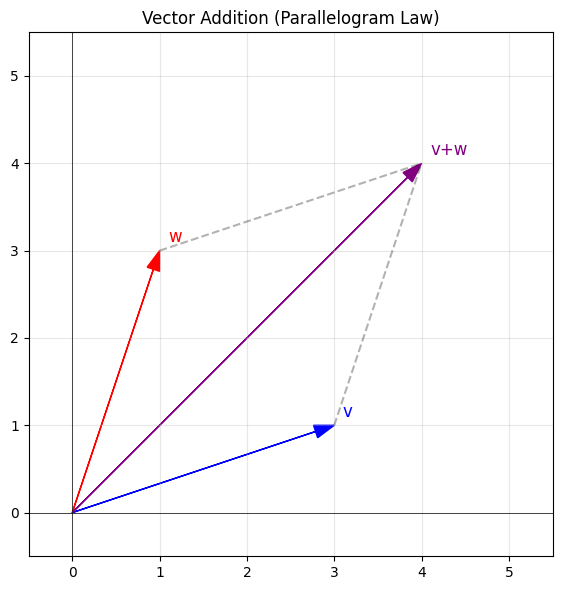

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
v = np.array([3, 1])
w = np.array([1, 3])
s = v + w

ax.arrow(0, 0, v[0], v[1], head_width=0.15, color='blue', length_includes_head=True, label='v')
ax.arrow(0, 0, w[0], w[1], head_width=0.15, color='red', length_includes_head=True, label='w')
ax.arrow(0, 0, s[0], s[1], head_width=0.15, color='purple', length_includes_head=True, label='v+w')
# Parallelogram
ax.plot([v[0], s[0]], [v[1], s[1]], 'k--', alpha=0.3)
ax.plot([w[0], s[0]], [w[1], s[1]], 'k--', alpha=0.3)

ax.text(v[0]+0.1, v[1]+0.1, 'v', fontsize=12, color='blue')
ax.text(w[0]+0.1, w[1]+0.1, 'w', fontsize=12, color='red')
ax.text(s[0]+0.1, s[1]+0.1, 'v+w', fontsize=12, color='purple')

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Vector Addition (Parallelogram Law)')
plt.tight_layout()
plt.show()

### Eigenvectors: Directions Preserved by a Matrix

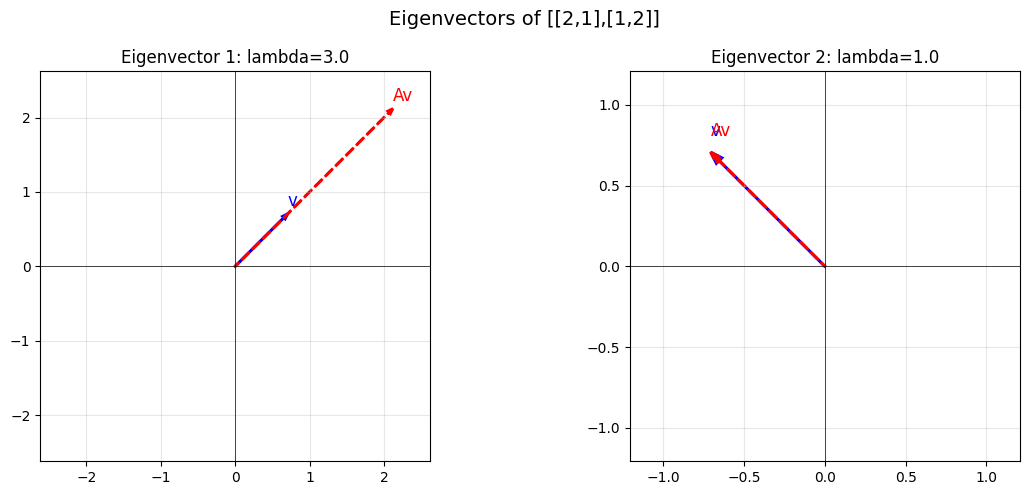

In [74]:
A = np.array([[2, 1], [1, 2]], dtype=float)
vals, vecs = np.linalg.eig(A)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, ax in enumerate(axes):
    v = vecs[:, idx]
    Av = A @ v
    ax.arrow(0, 0, v[0], v[1], head_width=0.05, color='blue',
             length_includes_head=True, linewidth=2)
    ax.arrow(0, 0, Av[0], Av[1], head_width=0.05, color='red',
             length_includes_head=True, linewidth=2, linestyle='--')
    ax.set_title(f'Eigenvector {idx+1}: lambda={vals[idx]:.1f}')
    ax.text(v[0], v[1]+0.1, 'v', color='blue', fontsize=12)
    ax.text(Av[0], Av[1]+0.1, 'Av', color='red', fontsize=12)
    lim = max(abs(Av[0]), abs(Av[1])) + 0.5
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle('Eigenvectors of [[2,1],[1,2]]', fontsize=14)
plt.tight_layout()
plt.show()

### Hadamard Gate: From Basis States to Superposition

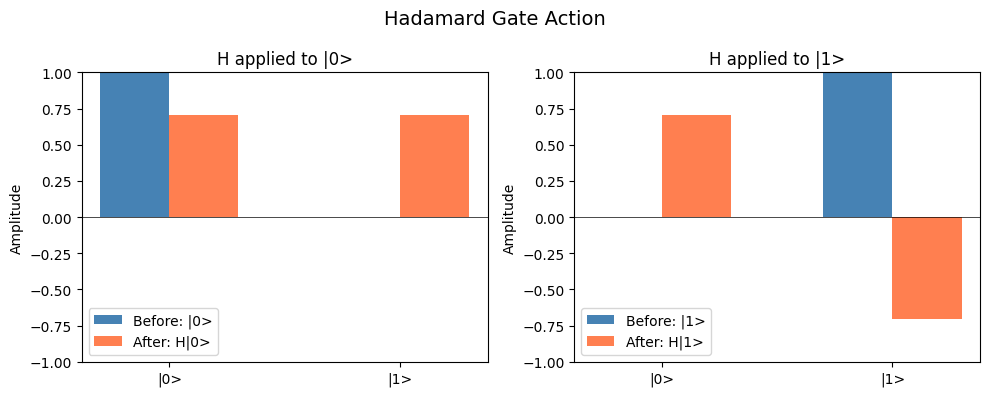

In [75]:
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]])

states = {'|0>': np.array([1, 0]), '|1>': np.array([0, 1])}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, s) in zip(axes, states.items()):
    Hs = H @ s
    labels = ['|0>', '|1>']
    x = np.arange(2)
    ax.bar(x - 0.15, s, 0.3, label=f'Before: {name}', color='steelblue')
    ax.bar(x + 0.15, Hs, 0.3, label=f'After: H{name}', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'H applied to {name}')
    ax.legend()
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='black', linewidth=0.5)

plt.suptitle('Hadamard Gate Action', fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 2.4.9

Show that $\langle V, c \cdot W \rangle = c \cdot \langle V, W \rangle$ (linearity in the second argument).

**Proof.** $\langle V, cW \rangle = V^\dagger (cW) = c (V^\dagger W) = c \langle V, W \rangle$. $\square$

In [76]:
c = 2+3j
v = cvec(1+1j, 2)
w = cvec(3, -1j)
assert np.isclose(inner(v, c*w), c * inner(v, w))
print('Linearity in second argument verified.')

Linearity in second argument verified.


### Exercise 2.4.10

Show that $\langle c \cdot V, W \rangle = \bar{c} \cdot \langle V, W \rangle$ (conjugate-linearity in the first argument).

**Proof.** $\langle cV, W \rangle = (cV)^\dagger W = \bar{c} V^\dagger W = \bar{c} \langle V, W \rangle$. $\square$

In [77]:
assert np.isclose(inner(c*v, w), np.conj(c) * inner(v, w))
print('Conjugate-linearity in first argument verified.')

Conjugate-linearity in first argument verified.


### Exercise 2.4.11

Prove the Cauchy-Schwarz inequality: $|\langle V, W \rangle| \leq \|V\| \cdot \|W\|$.

**Proof sketch.** For any scalar $t$, $\|V - tW\|^2 \geq 0$. Expanding and choosing $t = \langle W, V \rangle / \|W\|^2$ yields the result after simplification. $\square$

In [78]:
v = cvec(1+2j, 3-1j, 2)
w = cvec(2, 1+1j, -3j)
print('|<v,w>| =', abs(inner(v, w)))
print('||v|| * ||w|| =', norm(v) * norm(w))
assert abs(inner(v, w)) <= norm(v) * norm(w) + 1e-10
print('Cauchy-Schwarz holds.')

|<v,w>| = 7.211102550927978
||v|| * ||w|| = 16.881943016134134
Cauchy-Schwarz holds.


### Exercise 2.4.12

Prove the triangle inequality: $\|V + W\| \leq \|V\| + \|W\|$.

**Proof sketch.** $\|V+W\|^2 = \|V\|^2 + 2\text{Re}\langle V,W \rangle + \|W\|^2 \leq \|V\|^2 + 2|\langle V,W \rangle| + \|W\|^2 \leq (\|V\| + \|W\|)^2$ by Cauchy-Schwarz. $\square$

In [79]:
print('||v+w|| =', norm(v + w))
print('||v|| + ||w|| =', norm(v) + norm(w))
assert norm(v + w) <= norm(v) + norm(w) + 1e-10
print('Triangle inequality holds.')

||v+w|| = 6.48074069840786
||v|| + ||w|| = 8.231882289748091
Triangle inequality holds.


### Exercise 2.5.5

Find the eigenvalues and eigenvectors of the Pauli $\sigma_y$ matrix.

In [80]:
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
vals, vecs = eig(sigma_y)
print('Eigenvalues:', vals)
print('Eigenvectors:')
print(vecs)
for i in range(2):
    assert np.allclose(sigma_y @ vecs[:,i:i+1], vals[i] * vecs[:,i:i+1])
print('Verified.')

Eigenvalues: [ 1.+0.j -1.-0.j]
Eigenvectors:
[[-0.    -0.7071j  0.7071+0.j    ]
 [ 0.7071+0.j     -0.    -0.7071j]]
Verified.


### Exercise 2.5.6

Find the eigenvalues and eigenvectors of the Hadamard matrix.

In [81]:
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
vals, vecs = eig(H)
print('Eigenvalues:', vals)
print('Eigenvectors:')
print(vecs)
for i in range(2):
    assert np.allclose(H @ vecs[:,i:i+1], vals[i] * vecs[:,i:i+1])
print('Verified.')

Eigenvalues: [ 1.+0.j -1.+0.j]
Eigenvectors:
[[ 0.9239+0.j -0.3827+0.j]
 [ 0.3827+0.j  0.9239+0.j]]
Verified.


### Exercise 2.5.7

Show that if $\lambda$ is an eigenvalue of $A$, then $\bar{\lambda}$ is an eigenvalue of $A^\dagger$.

**Proof.** $AV = \lambda V$ implies $V^\dagger A^\dagger = \bar{\lambda} V^\dagger$. Taking the adjoint of both sides: $A^\dagger (V^\dagger)^\dagger = \bar{\lambda} (V^\dagger)^\dagger$, so $A^\dagger V = \bar{\lambda} V$ (since $(V^\dagger)^\dagger = V$ for column vectors). $\square$

In [82]:
A = np.array([[1+1j, 2], [3, 4-2j]], dtype=complex)
vals_A, _ = eig(A)
vals_Ad, _ = eig(A.conj().T)
print('Eigenvalues of A:', np.sort(vals_A))
print('Eigenvalues of A^dagger:', np.sort(vals_Ad))
print('Conjugates match?', np.allclose(np.sort(np.conj(vals_A)), np.sort(vals_Ad)))

Eigenvalues of A: [-0.0981+0.366j  5.0981-1.366j]
Eigenvalues of A^dagger: [-0.0981-0.366j  5.0981+1.366j]
Conjugates match? True


### Exercise 2.6.10

Show that the identity matrix is both Hermitian and unitary.

In [83]:
I = np.eye(3, dtype=complex)
print('Hermitian?', np.allclose(I, I.conj().T))
print('Unitary?', np.allclose(I.conj().T @ I, np.eye(3)))

Hermitian? True
Unitary? True


### Exercise 2.6.11

Find a $2 \times 2$ unitary matrix that is not Hermitian.

In [84]:
# Rotation by pi/4 is unitary but not Hermitian
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]], dtype=complex)
print('R =')
print(R)
print('Unitary?', np.allclose(R.conj().T @ R, np.eye(2)))
print('Hermitian?', np.allclose(R, R.conj().T))

R =
[[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]
Unitary? True
Hermitian? False


### Exercise 2.6.12

Show that if $A$ is Hermitian and $U$ is unitary, then $U A U^\dagger$ is Hermitian.

In [85]:
A = np.array([[3, 1-1j], [1+1j, 2]], dtype=complex)  # Hermitian
U = H  # Unitary
B = U @ A @ U.conj().T
print('UAU^dagger Hermitian?', np.allclose(B, B.conj().T))

UAU^dagger Hermitian? True


### Exercise 2.6.13

Verify that the trace of a Hermitian matrix is real.

**Proof.** $\text{tr}(A) = \sum A[j,j]$. For Hermitian $A$, all diagonal entries satisfy $A[j,j] = \overline{A[j,j]}$, so they are real. The sum of reals is real. $\square$

In [86]:
A = np.array([[3, 1-1j, 2j], [1+1j, 5, -3], [-2j, -3, 7]], dtype=complex)
print('Hermitian?', np.allclose(A, A.conj().T))
print('Trace:', np.trace(A))
print('Trace is real?', np.isclose(np.trace(A).imag, 0))

Hermitian? True
Trace: (15+0j)
Trace is real? True


### Exercise 2.7.11

Compute $\sigma_x \otimes \sigma_z$.

In [87]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
print('sigma_x tensor sigma_z =')
print(np.kron(sx, sz))

sigma_x tensor sigma_z =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j -0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -0.+0.j]]


### Exercise 2.7.12

Verify that $\sigma_x \otimes I$ and $I \otimes \sigma_x$ act on different qubits.

In [88]:
I2 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)

# sigma_x on qubit 0 (first qubit)
op1 = np.kron(sx, I2)
# sigma_x on qubit 1 (second qubit)
op2 = np.kron(I2, sx)

psi = cvec(1, 0, 0, 0)  # |00>
print('(sx tensor I)|00> =', (op1 @ psi).flatten(), ' = |10>')
print('(I tensor sx)|00> =', (op2 @ psi).flatten(), ' = |01>')

(sx tensor I)|00> = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]  = |10>
(I tensor sx)|00> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]  = |01>


### Exercise 2.7.13

Show that associativity holds: $(V \otimes W) \otimes X = V \otimes (W \otimes X)$.

In [89]:
v = cvec(1+1j, 2)
w = cvec(3, -1j)
x = cvec(0, 1)
lhs = np.kron(np.kron(v, w), x)
rhs = np.kron(v, np.kron(w, x))
assert np.allclose(lhs, rhs)
print('Associativity of tensor product verified.')

Associativity of tensor product verified.


### Programming Drill 2.7.3

Write a function to check separability by computing the Schmidt rank.

In [90]:
def schmidt_rank(psi, dim_a, dim_b):
    """Compute the Schmidt rank of a bipartite state."""
    M = psi.reshape(dim_a, dim_b)
    return np.linalg.matrix_rank(M, tol=1e-10)

# GHZ-like state in C^2 tensor C^2
bell = cvec(1, 0, 0, 1) / np.sqrt(2)
print('Bell state Schmidt rank:', schmidt_rank(bell, 2, 2))

product = np.kron(cvec(1, 0), cvec(1, 0))
print('|00> Schmidt rank:', schmidt_rank(product, 2, 2))

Bell state Schmidt rank: 2
|00> Schmidt rank: 1


## Summary

This chapter built the linear algebra toolkit for quantum computing, piece by piece:

- **Vectors and scalars** ($\mathbb{C}^n$): quantum states are column vectors with complex entries.
- **Matrices** ($\mathbb{C}^{n \times n}$): quantum operations are matrices that act on state vectors.
- **Transpose, conjugate, adjoint**: the dagger operation $A^\dagger$ is the fundamental tool.
- **Basis and dimension**: every finite-dimensional vector space has a basis; coordinates depend on the choice of basis.
- **Inner products and norms**: the inner product lets us measure lengths, distances, and angles. Quantum states must have norm 1.
- **Eigenvalues and eigenvectors**: special directions that a matrix preserves (up to scaling).
- **Hermitian matrices**: represent observables; have real eigenvalues and orthogonal eigenvectors.
- **Unitary matrices**: represent quantum gates; preserve inner products and norms.
- **Tensor products**: combine quantum systems; the Kronecker product builds joint state spaces.
- **Entanglement**: states that cannot be written as tensor products of subsystem states.

With these tools in hand, we are ready to describe actual quantum systems in Chapter 3.